In [1]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import Angle
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

In [2]:
data_folder = 'ADP_FLAMES_30Dor_30arcmin'

In [3]:
fits_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor") / data_folder

In [4]:
c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [5]:
#fov_deg = 1.0  # Total field of view in degrees (width and height)
#pix_scale = 1 / 3600
#npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
#wcs.wcs.crpix = [npix, npix]  # center of your "image"
#wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [6]:
from pathlib import Path
import pickle

base_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor")
pickle_path = base_dir / "flames30dor_dataframes.pkl"

with open(pickle_path, "rb") as f:
    df_dict = pickle.load(f)

df = df_dict["df"]
df_letter = df_dict["df_letter"]
df_pos = df_dict["df_pos"]
df_num = df_dict["df_num"]

print(df_dict.keys())
print(df_letter.head())

dict_keys(['df', 'df_letter', 'df_pos', 'df_num'])
                              filename object                 date_obs  \
2336  ADP.2019-01-31T23_53_42.007.fits    t60  2003-12-03T03:42:56.961   
2337  ADP.2019-01-31T23_53_42.024.fits    t29  2003-12-03T05:54:18.706   
2338  ADP.2019-01-31T23_53_42.039.fits    u37  2003-12-03T01:44:39.244   
2339  ADP.2019-01-31T23_53_42.048.fits    t56  2003-12-03T01:44:39.244   
2341  ADP.2019-01-31T23_53_42.079.fits    u10  2003-12-03T03:42:56.961   

           mjd_obs instrument   telescope                           arcfile  \
2336  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.007.fits   
2337  52976.246050    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.024.fits   
2338  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.039.fits   
2339  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.048.fits   
2341  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.079.fits   

            prog_id          

# Regular grid

In [7]:
df_letter

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group
2336,ADP.2019-01-31T23_53_42.007.fits,t60,2003-12-03T03:42:56.961,52976.154826,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.007.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.721708,-69.077750,1199.9699,1200.0,t60_ra84.721708_dec-69.07775_exp1200.0,letter_two_digits
2337,ADP.2019-01-31T23_53_42.024.fits,t29,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.024.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.628250,-69.066639,1199.9741,1200.0,t29_ra84.62825_dec-69.066639_exp1200.0,letter_two_digits
2338,ADP.2019-01-31T23_53_42.039.fits,u37,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.039.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.908583,-69.122194,1199.9691,1200.0,u37_ra84.908583_dec-69.122194_exp1200.0,letter_two_digits
2339,ADP.2019-01-31T23_53_42.048.fits,t56,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.048.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.690542,-69.111083,1199.9691,1200.0,t56_ra84.690542_dec-69.111083_exp1200.0,letter_two_digits
2341,ADP.2019-01-31T23_53_42.079.fits,u10,2003-12-03T03:42:56.961,52976.154826,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.079.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.784000,-69.066639,1199.9699,1200.0,u10_ra84.784_dec-69.066639_exp1200.0,letter_two_digits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4514,ADP.2019-09-04T13_34_27.424.fits,u40,2003-12-03T03:14:13.205,52976.134875,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.424.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.908583,-69.088861,599.9858,600.0,u40_ra84.908583_dec-69.088861_exp600.0,letter_two_digits
4515,ADP.2019-09-04T13_34_27.426.fits,u15,2003-12-03T02:41:30.802,52976.112162,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.426.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.784000,-69.099972,599.9847,600.0,u15_ra84.784_dec-69.099972_exp600.0,letter_two_digits
4516,ADP.2019-09-04T13_34_27.428.fits,t44,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.428.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.628250,-69.088861,599.9857,600.0,t44_ra84.62825_dec-69.088861_exp600.0,letter_two_digits
4517,ADP.2019-09-04T13_34_27.430.fits,u25,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.430.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.815125,-69.099972,599.9857,600.0,u25_ra84.815125_dec-69.099972_exp600.0,letter_two_digits


# Plot data points

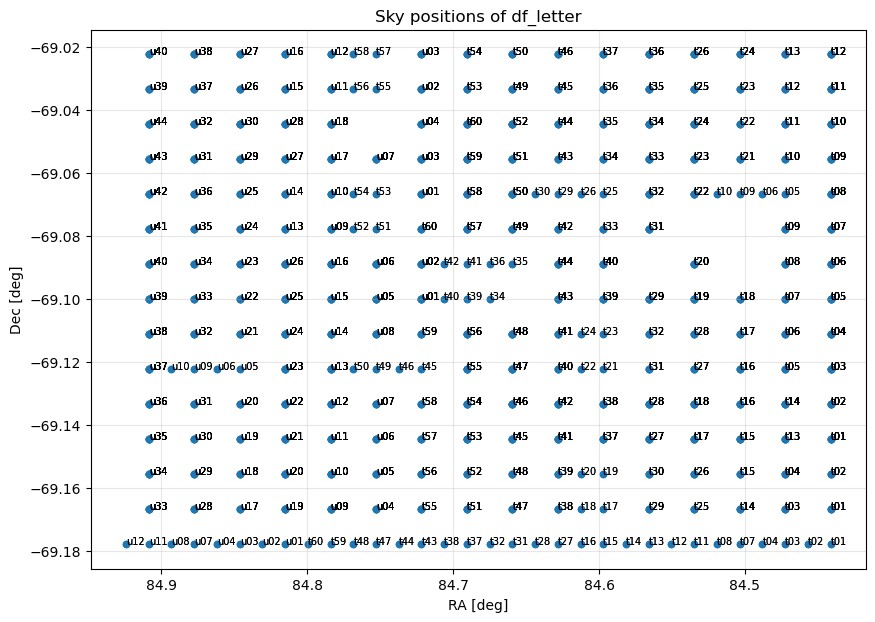

In [8]:
df_plot = df_letter.dropna(subset=["ra_deg", "dec_deg"]).copy()

plt.figure(figsize=(10, 7))
plt.scatter(df_plot["ra_deg"], df_plot["dec_deg"], s=20)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    plt.text(row["ra_deg"], row["dec_deg"], label, fontsize=7)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions of df_letter")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

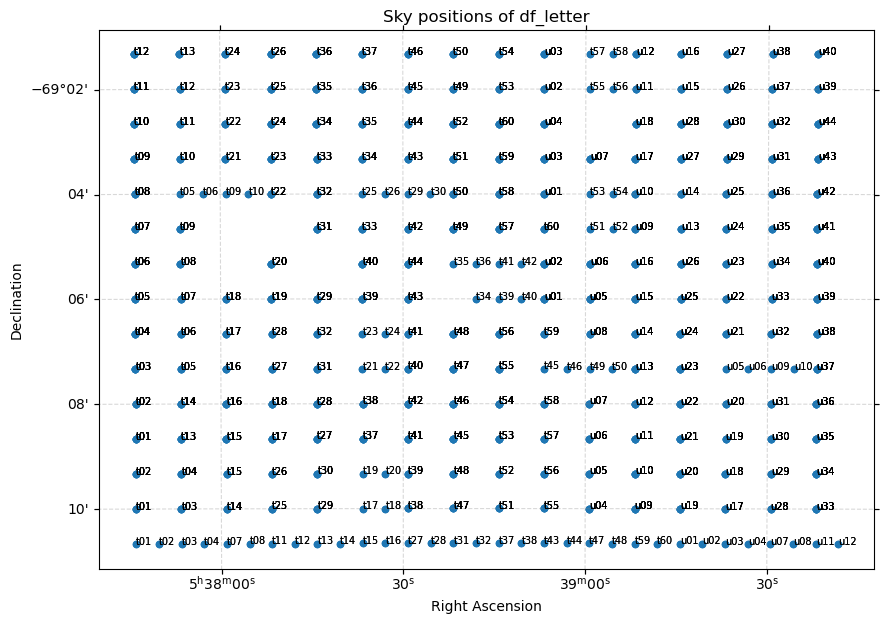

In [9]:
df_plot = df_letter.dropna(subset=["ra_deg", "dec_deg"]).copy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

ax.scatter(
    df_plot["ra_deg"],
    df_plot["dec_deg"],
    s=20,
    transform=ax.get_transform("world")
)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        transform=ax.get_transform("world")
    )

ax.set_title("Sky positions of df_letter")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")

plt.show()

Load spetra

In [10]:
from pathlib import Path
from astropy.io import fits

# Folder where the FITS files are stored

letter_spectra = []

for _, row in df_letter.iterrows():
    fits_path = fits_dir / row["filename"]

    try:
        with fits.open(fits_path) as hdul:
            spec = hdul[1].data

            wave = spec["WAVE"][0]
            flux = spec["FLUX_REDUCED"][0]
            err  = spec["ERR_REDUCED"][0]
#            snr  = spec["SNR"][0]

            letter_spectra.append({
                "filename": row["filename"],
                "object": row["object"],
                "ra_deg": row["ra_deg"],
                "dec_deg": row["dec_deg"],
                "wave": wave,
                "flux": flux,
                "err": err,
#                "snr": snr,
            })

    except Exception as e:
        print(f"Could not read {fits_path.name}: {e}")

print(f"Loaded {len(letter_spectra)} spectra from df_letter")

Loaded 1339 spectra from df_letter


In [11]:
def plot_spectra_subset(spectra_list, wmin, wmax, normalize=False):
    plt.figure(figsize=(12, 6))

    for spec in spectra_list:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        wave_zoom = wave[mask]
        flux_zoom = flux[mask]

        if len(wave_zoom) == 0:
            continue

        if normalize and flux_zoom.max() != 0:
            flux_zoom = flux_zoom / flux_zoom.max()

        plt.plot(wave_zoom, flux_zoom, alpha=0.7, lw=1)

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Normalized Flux" if normalize else "Reduced Flux [adu]")
    plt.title(f"Spectra zoom: {wmin}–{wmax} nm")
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
#letter_spectra

In [13]:
#plot_spectra_subset(letter_spectra, 655, 658, normalize=True)

Export one PNG per spectrum

Script for one object family.

In [14]:
from pathlib import Path
import pandas as pd
from astropy.io import fits

# Example: only t01
df_t01 = df_letter[df_letter["object"].astype(str).str.strip().str.lower() == "t01"].copy()

keys = [
    "OBJECT",
    "DATE",
    "DATE-OBS",
    "MJD-OBS",
    "EXPTIME",
    "INSTRUME",
    "TELESCOP",
    "RA",
    "DEC",
    "ARCFILE",
    "HIERARCH ESO OBS PROG ID",
    "HIERARCH ESO OBS NAME",
    "HIERARCH ESO DPR CATG",
    "HIERARCH ESO DPR TYPE",
    "HIERARCH ESO DPR TECH",
    "HIERARCH ESO PRO CATG",
    "HIERARCH ESO PRO TECH",
    "HIERARCH ESO PRO REC1 ID",
    "HIERARCH ESO PRO REC1 PIPE ID",
    "HIERARCH ESO PRO REC1 RAW1 NAME",
]

rows = []

for _, row in df_t01.iterrows():
    fpath = fits_dir / row["filename"]
    with fits.open(fpath) as hdul:
        hdr = hdul[0].header

    out = {"filename": row["filename"]}
    for k in keys:
        out[k] = hdr.get(k)
    rows.append(out)

df_t01_hdr = pd.DataFrame(rows)
print(df_t01_hdr)

                            filename OBJECT                 DATE  \
0   ADP.2019-01-31T23_53_43.542.fits    t01  2018-12-11T23:44:55   
1   ADP.2019-01-31T23_53_43.810.fits    t01  2018-12-11T23:41:12   
2   ADP.2019-01-31T23_53_45.680.fits    t01  2018-12-11T23:48:11   
3   ADP.2019-01-31T23_53_45.773.fits    t01  2018-12-11T23:49:32   
4   ADP.2019-05-20T15_43_46.585.fits    t01  2019-03-13T15:19:39   
5   ADP.2019-09-04T13_34_25.653.fits    t01  2019-08-29T15:26:31   
6   ADP.2019-09-04T13_34_25.763.fits    t01  2019-08-29T15:26:12   
7   ADP.2019-09-04T13_34_26.029.fits    t01  2019-08-29T15:26:12   
8   ADP.2019-09-04T13_34_26.307.fits    t01  2019-08-29T15:26:31   
9   ADP.2019-09-04T13_34_26.429.fits    t01  2019-08-29T15:26:12   
10  ADP.2019-09-04T13_34_26.521.fits    t01  2019-08-29T15:26:12   
11  ADP.2019-09-04T13_34_26.890.fits    t01  2019-08-29T15:26:13   
12  ADP.2019-09-04T13_34_26.986.fits    t01  2019-08-29T15:26:31   
13  ADP.2019-09-04T13_34_27.326.fits    t01  201

In [15]:
cols = [
    "filename",
    "DATE-OBS",
    "EXPTIME",
    "RA",
    "DEC",
    "HIERARCH ESO OBS NAME",
    "HIERARCH ESO PRO CATG",
    "HIERARCH ESO PRO REC1 PIPE ID",
    "HIERARCH ESO PRO REC1 RAW1 NAME",
]

df_t01_hdr[cols].sort_values("DATE-OBS")

,filename,DATE-OBS,EXPTIME,RA,DEC,HIERARCH ESO OBS NAME,HIERARCH ESO PRO CATG,HIERARCH ESO PRO REC1 PIPE ID,HIERARCH ESO PRO REC1 RAW1 NAME
1,ADP.2019-01-31T23_53_43.810.fits,2003-12-03T01:44:39.244,1199.9691,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-03T01:55:30.602.fits
9,ADP.2019-09-04T13_34_26.429.fits,2003-12-03T02:19:40.767,599.9841,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T02:19:40.767.fits
13,ADP.2019-09-04T13_34_27.326.fits,2003-12-03T02:30:32.164,599.9848,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T02:30:32.164.fits
7,ADP.2019-09-04T13_34_26.029.fits,2003-12-03T02:41:30.802,599.9847,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T02:41:30.803.fits
6,ADP.2019-09-04T13_34_25.763.fits,2003-12-03T02:52:22.540,599.9857,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T02:52:22.541.fits
11,ADP.2019-09-04T13_34_26.890.fits,2003-12-03T03:03:21.958,599.9864,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T03:03:21.958.fits
10,ADP.2019-09-04T13_34_26.521.fits,2003-12-03T03:14:13.205,599.9858,84.441375,-69.144417,30Dor_P1,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T03:14:13.206.fits
0,ADP.2019-01-31T23_53_43.542.fits,2003-12-03T03:42:56.961,1199.9699,84.441375,-69.166639,30Dor_P2,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-03T03:55:48.298.fits
4,ADP.2019-05-20T15_43_46.585.fits,2003-12-03T04:19:56.443,41.9805,84.441375,-69.166639,30Dor_P2,SCIENCE_RBNSPEC_IDP,giraf/2.16.3,GIRAF.2003-12-03T04:19:56.443_PC_clean.fits
8,ADP.2019-09-04T13_34_26.307.fits,2003-12-03T04:26:30.672,599.9843,84.441375,-69.166639,30Dor_P2,SCIENCE_RBNSPEC_IDP,giraf/2.16.5,GIRAF.2003-12-03T04:26:30.672.fits


In [16]:
t01_spectra = [spec for spec in letter_spectra if str(spec["object"]).strip().lower() == "t01"]

In [17]:
t02_spectra = [spec for spec in letter_spectra if str(spec["object"]).strip().lower() == "t02"]

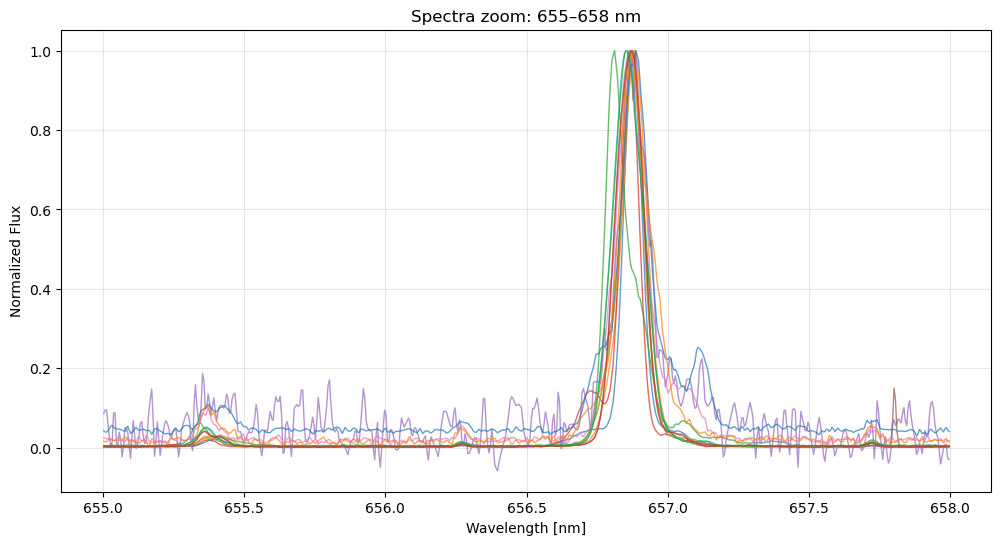

In [18]:
plot_spectra_subset(t02_spectra, 655, 658, normalize=True)

In [19]:
# Sample EXPTIME

In [34]:
df_letter["EXPTIME"].value_counts().sort_index()

EXPTIME
41.9805       98
599.9841     101
599.9843      98
599.9847     101
599.9848     101
599.9857     101
599.9858     101
599.9864     101
599.9865      98
599.9871      98
1199.9691    101
1199.9699     98
1199.9741     71
1199.9750     71
Name: count, dtype: int64

# Sample exposure time

In [36]:
df_expA = df_letter[df_letter["EXPTIME"] == 41.9805].copy()
df_expB = df_letter[df_letter["EXPTIME"] == 599.9841].copy()
df_expC = df_letter[df_letter["EXPTIME"] == 599.9843].copy()
df_expD = df_letter[df_letter["EXPTIME"] == 599.9847].copy()
df_expE = df_letter[df_letter["EXPTIME"] == 599.9848].copy()
df_expF = df_letter[df_letter["EXPTIME"] == 599.9857].copy()
df_expG = df_letter[df_letter["EXPTIME"] == 599.9858].copy()
df_expH = df_letter[df_letter["EXPTIME"] == 599.9864].copy()
df_expI = df_letter[df_letter["EXPTIME"] == 599.9865].copy()
df_expJ = df_letter[df_letter["EXPTIME"] == 599.9871].copy()
df_expW = df_letter[df_letter["EXPTIME"] == 1199.9691].copy()
df_expX = df_letter[df_letter["EXPTIME"] == 1199.9699].copy()
df_expY = df_letter[df_letter["EXPTIME"] == 1199.9741].copy()
df_expZ = df_letter[df_letter["EXPTIME"] == 1199.9750].copy()

In [37]:
df_plotA = df_expA.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotB = df_expB.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotC = df_expC.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotD = df_expD.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotE = df_expE.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotF = df_expF.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotG = df_expG.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotH = df_expH.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotI = df_expI.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotJ = df_expJ.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotW = df_expW.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotX = df_expX.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotY = df_expY.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotZ = df_expZ.dropna(subset=["ra_deg", "dec_deg"]).copy()

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_sky_positions(df_plot, wcs, title="Sky positions", color="blue", marker="s", size=20, fontsize=7):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    ax.scatter(
        df_plot["ra_deg"],
        df_plot["dec_deg"],
        s=size,
        marker=marker,
        color=color,
        transform=ax.get_transform("world")
    )

    for _, row in df_plot.iterrows():
        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
        ax.text(
            row["ra_deg"],
            row["dec_deg"],
            label,
            fontsize=fontsize,
            transform=ax.get_transform("world")
        )

    ax.set_title(title)
    ax.coords[0].set_axislabel("Right Ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.grid(color="gray", alpha=0.3, linestyle="--")
    ax.invert_xaxis()

    plt.show()

In [39]:
dfs = {
    "A": df_plotA,
    "B": df_plotB,
    "C": df_plotC,
    "D": df_plotD,
    "E": df_plotE,
    "F": df_plotF,
    "G": df_plotG,
    "H": df_plotH,
    "I": df_plotI,
    "J": df_plotJ,
    "W": df_plotW,
    "X": df_plotX,
    "Y": df_plotY,
    "Z": df_plotZ,
}

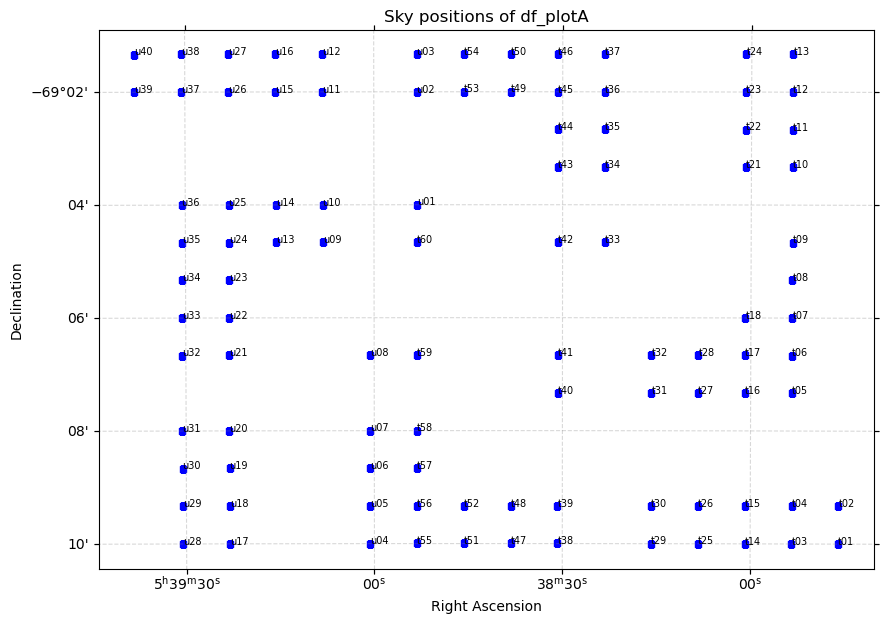

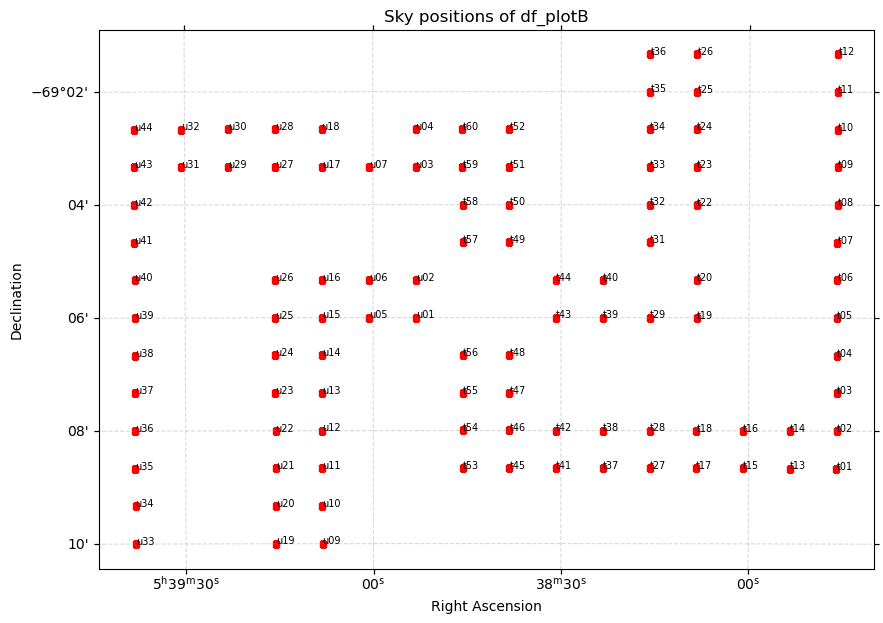

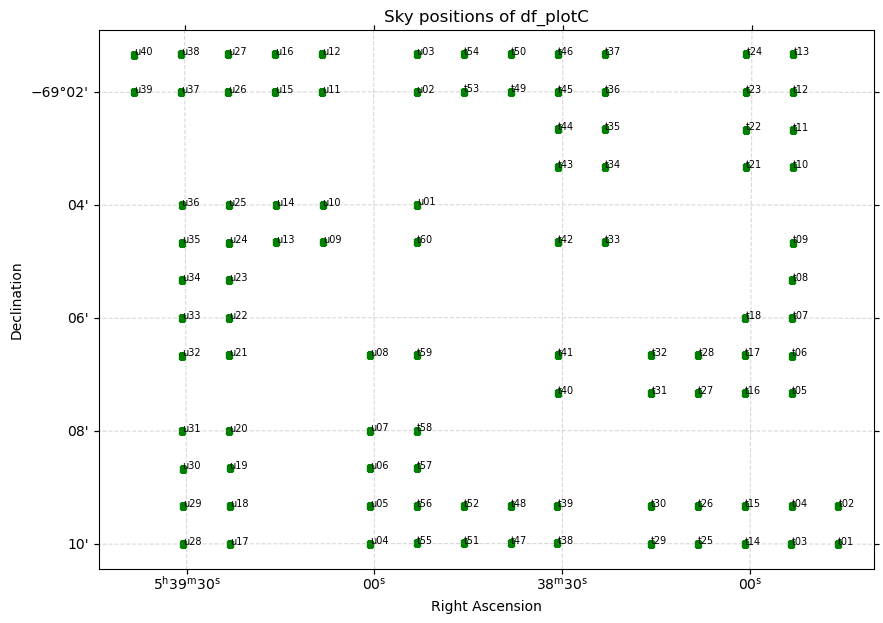

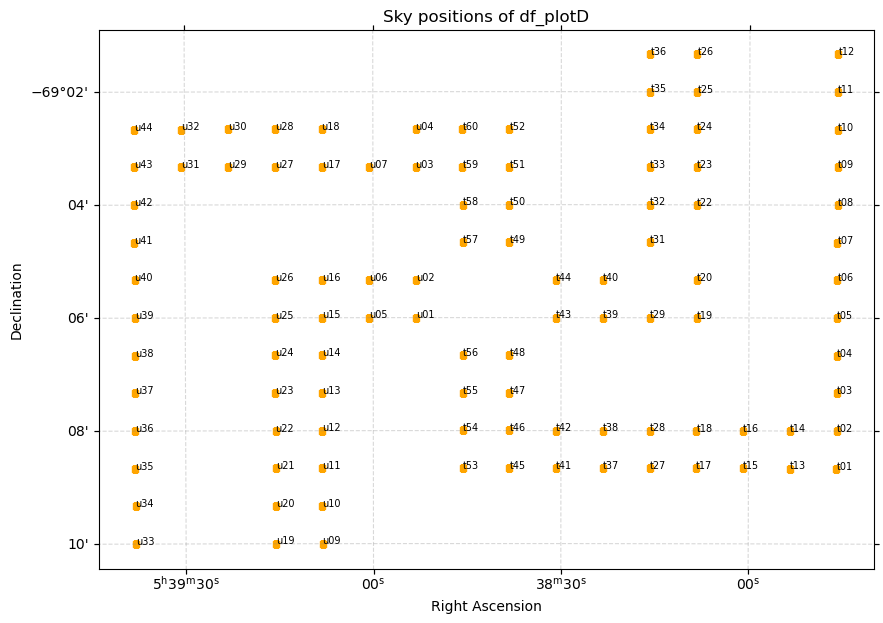

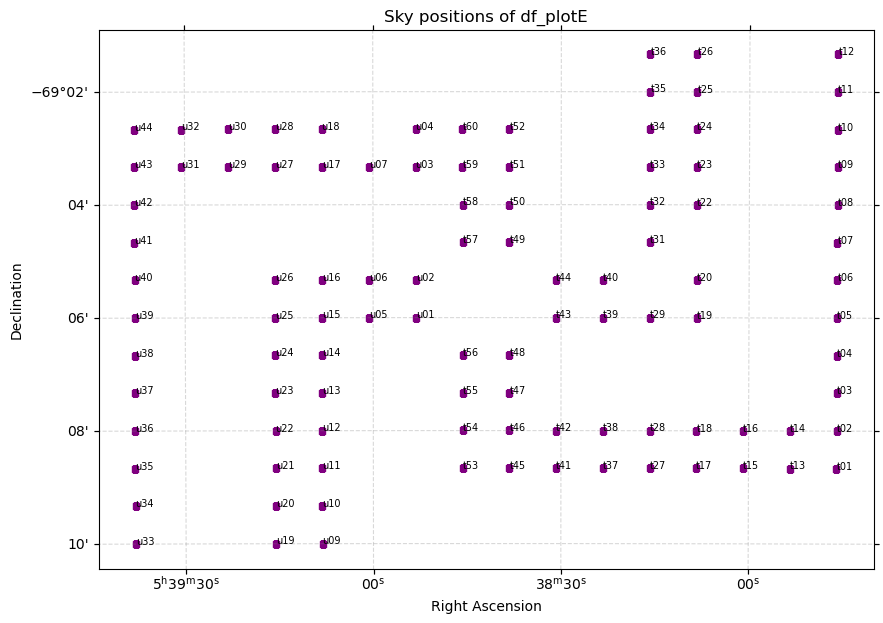

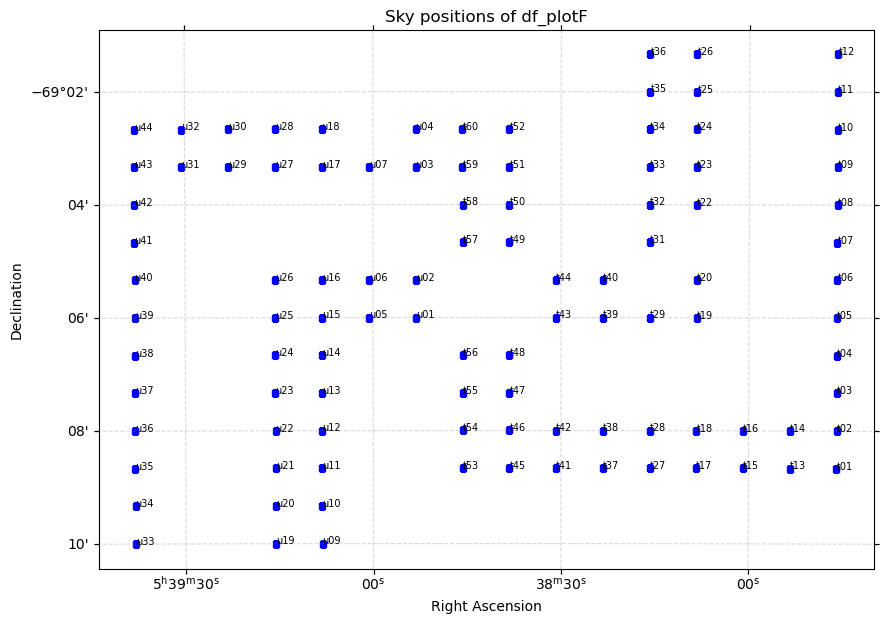

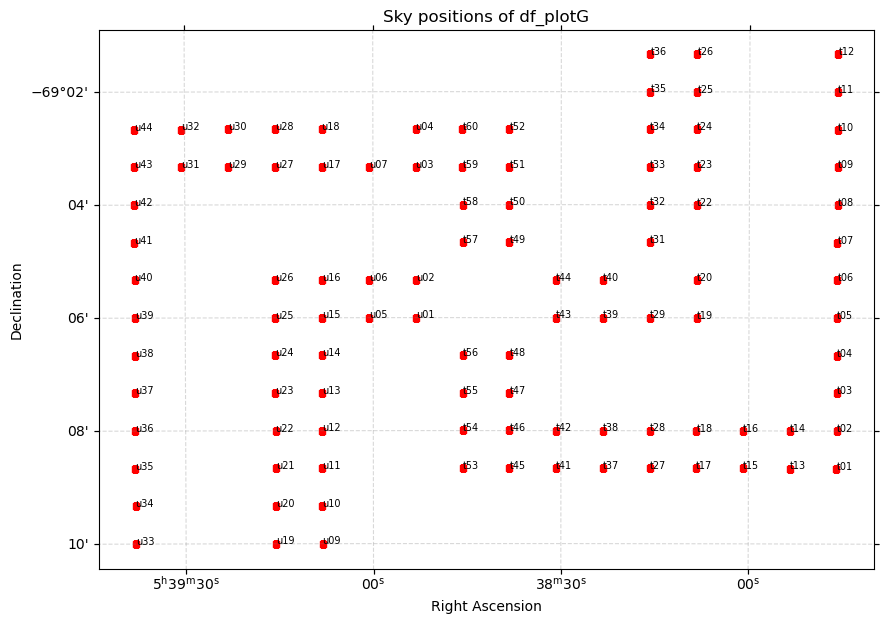

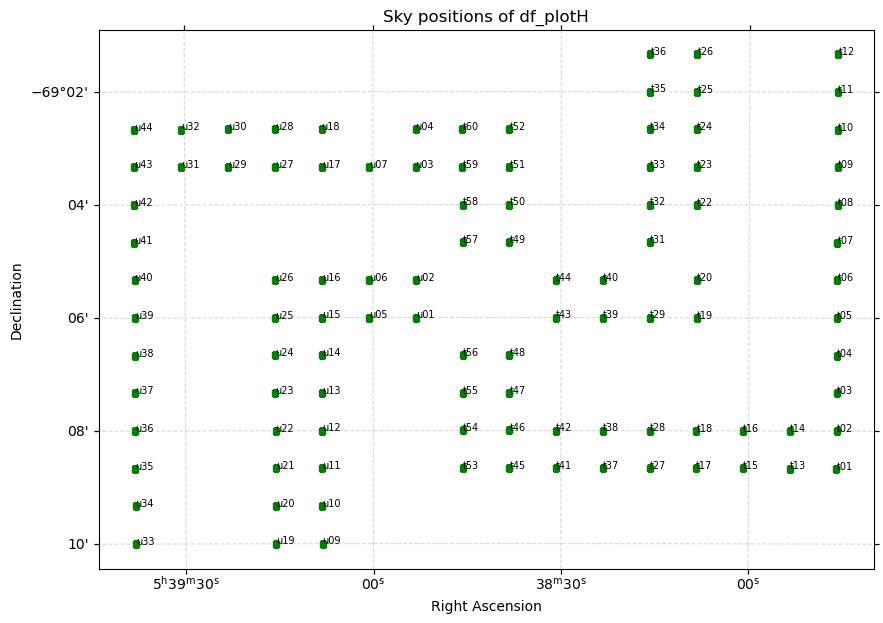

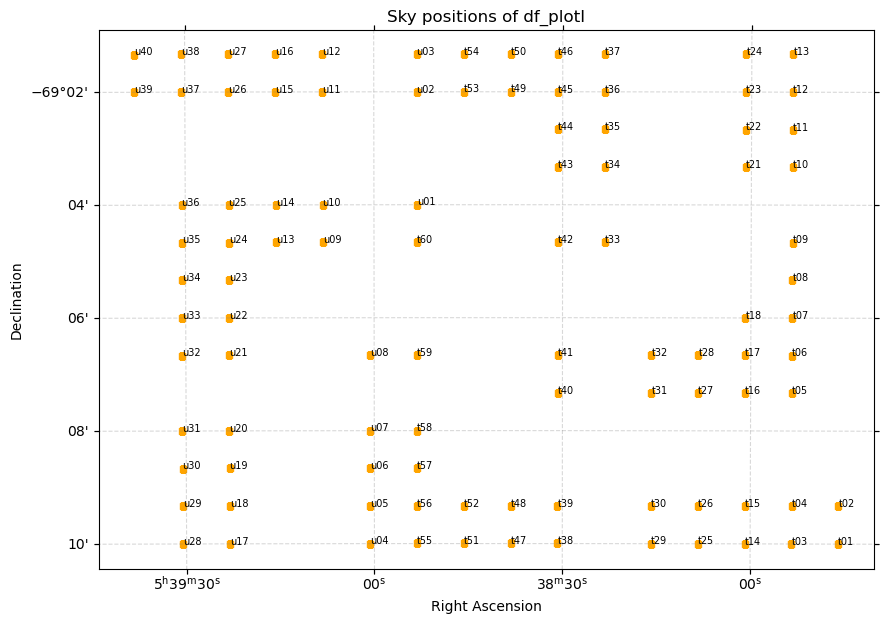

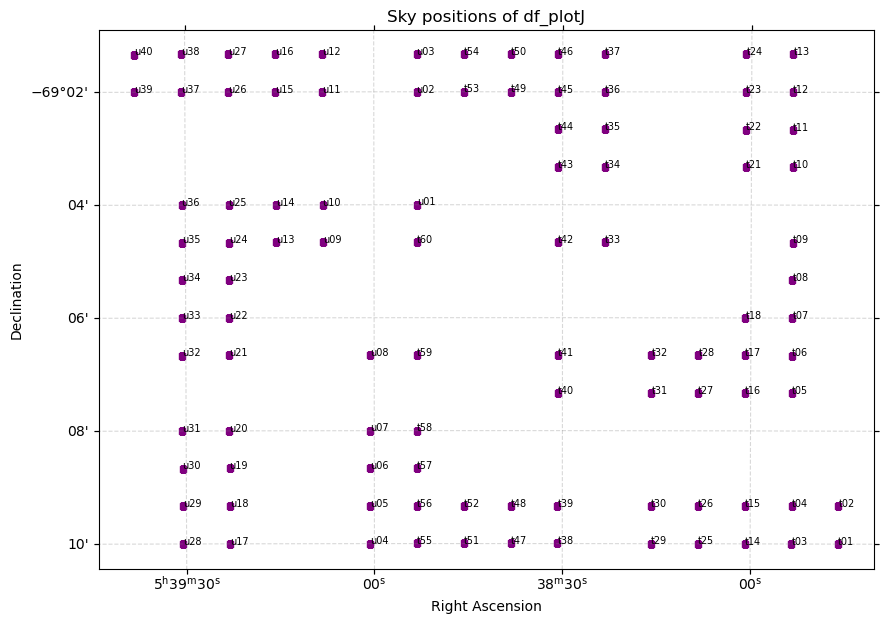

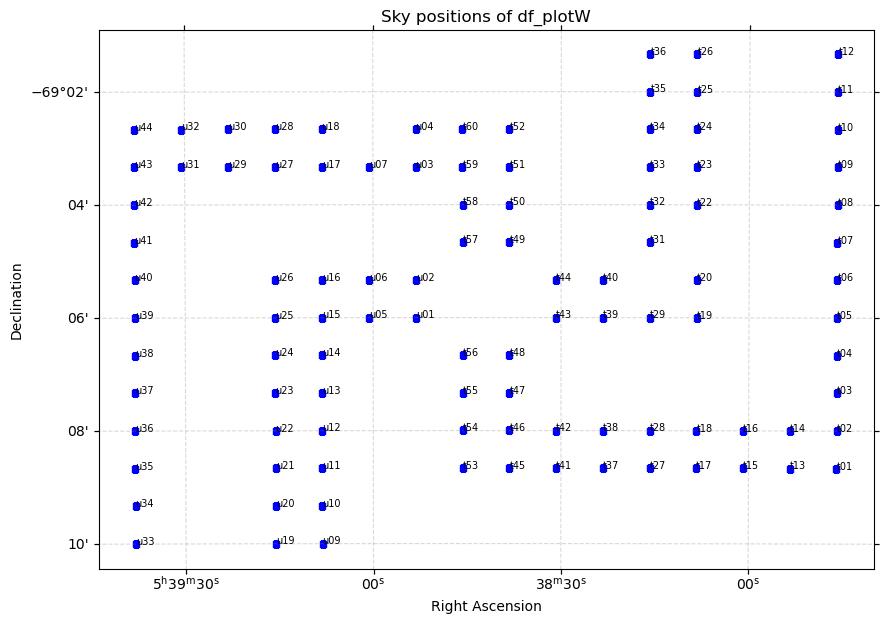

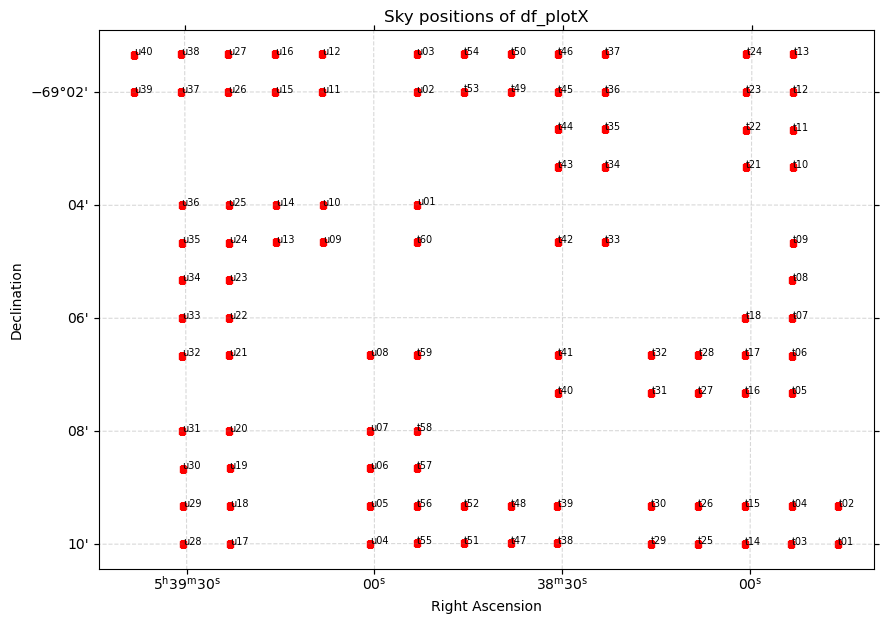

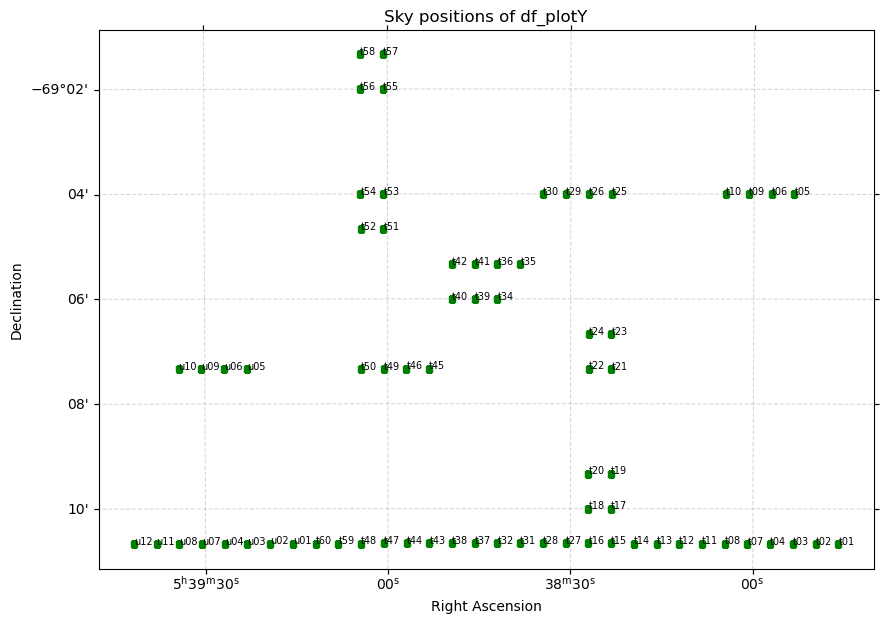

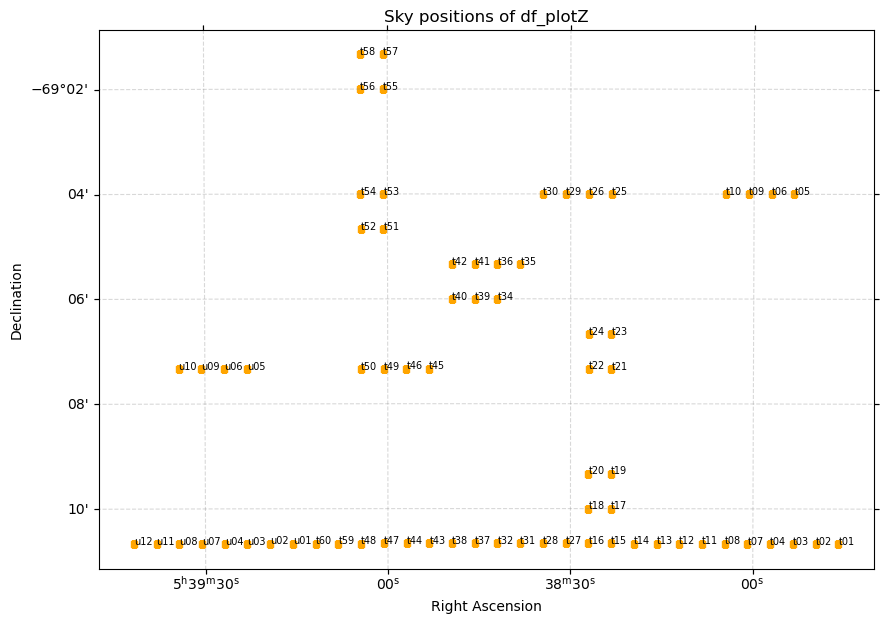

In [41]:
colors = ["blue", "red", "green", "orange", "purple","blue", "red", "green", "orange", "purple","blue", "red", "green", "orange"]

for (name, df_plot), color in zip(dfs.items(), colors):
    plot_sky_positions(df_plot, wcs, title=f"Sky positions of df_plot{name}", color=color)

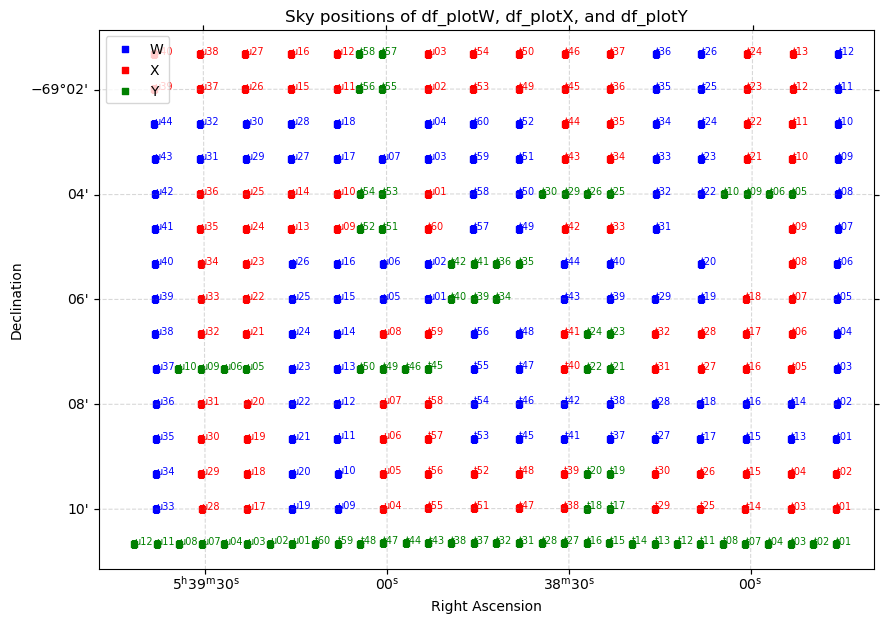

In [48]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# df_plotW
ax.scatter(
    df_plotW["ra_deg"],
    df_plotW["dec_deg"],
    s=20,
    marker="s",
    color="blue",
    label="W",
    transform=ax.get_transform("world")
)

for _, row in df_plotW.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        color="blue",
        transform=ax.get_transform("world")
    )

# df_plotX
ax.scatter(
    df_plotX["ra_deg"],
    df_plotX["dec_deg"],
    s=20,
    marker="s",
    color="red",
    label="X",
    transform=ax.get_transform("world")
)

for _, row in df_plotX.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        color="red",
        transform=ax.get_transform("world")
    )

# df_plotY
ax.scatter(
    df_plotY["ra_deg"],
    df_plotY["dec_deg"],
    s=20,
    marker="s",
    color="green",
    label="Y",
    transform=ax.get_transform("world")
)

for _, row in df_plotY.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        color="green",
        transform=ax.get_transform("world")
    )

ax.set_title("Sky positions of df_plotW, df_plotX, and df_plotY")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
ax.legend()

ax.invert_xaxis()
plt.show()

# Data EXPTIME samples

Load spectra

In [42]:
from pathlib import Path
from astropy.io import fits
import pandas as pd

def load_spectra_from_df(df, fits_dir, flux_col="FLUX_REDUCED", err_col="ERR_REDUCED"):
    spectra = []

    for _, row in df.iterrows():
        fits_path = fits_dir / row["filename"]

        try:
            with fits.open(fits_path) as hdul:
                spec = hdul[1].data

                wave = spec["WAVE"][0]
                flux = spec[flux_col][0]
                err  = spec[err_col][0]

                spectra.append({
                    "filename": row["filename"],
                    "object": row["object"],
                    "ra_deg": row["ra_deg"],
                    "dec_deg": row["dec_deg"],
                    "wave": wave,
                    "flux": flux,
                    "err": err,
                })

        except Exception as e:
            print(f"Could not read {fits_path.name}: {e}")

    print(f"Loaded {len(spectra)} spectra")
    return spectra

In [43]:
dfs_exp = {
    "A": df_expA,
    "B": df_expB,
    "C": df_expC,
    "D": df_expD,
    "E": df_expE,
    "F": df_expF,
    "G": df_expG,
    "H": df_expH,
    "I": df_expI,
    "J": df_expJ,
    "W": df_expW,
    "X": df_expX,
    "Y": df_expY,
    "Z": df_expZ
}

In [52]:
spectra_dict = {}

for name, df in dfs_exp.items():
    print(f"\nLoading spectra for group {name}")
    spectra_dict[name] = load_spectra_from_df(df, fits_dir)


Loading spectra for group A
Loaded 98 spectra

Loading spectra for group B
Loaded 101 spectra

Loading spectra for group C
Loaded 98 spectra

Loading spectra for group D
Loaded 101 spectra

Loading spectra for group E
Loaded 101 spectra

Loading spectra for group F
Loaded 101 spectra

Loading spectra for group G
Loaded 101 spectra

Loading spectra for group H
Loaded 101 spectra

Loading spectra for group I
Loaded 98 spectra

Loading spectra for group J
Loaded 98 spectra

Loading spectra for group W
Loaded 101 spectra

Loading spectra for group X
Loaded 98 spectra

Loading spectra for group Y
Loaded 71 spectra

Loading spectra for group Z
Loaded 71 spectra


In [45]:
def save_zoom_plots(spectra, outdir_name, wmin=655, wmax=658):
    outdir = Path(outdir_name)
    outdir.mkdir(exist_ok=True)

    for spec in spectra:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(wave[mask], flux[mask])
        ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel("Reduced Flux [adu]")
        ax.set_title(f"{spec['object']} | {spec['filename']} | {wmin}–{wmax} nm")
        ax.grid(True, alpha=0.3)

        obj = str(spec["object"]).replace("/", "_").replace("\\", "_").replace(" ", "_")
        base = Path(spec["filename"]).stem
        fname = outdir / f"{obj}_{base}_{wmin}_{wmax}.png"

        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved {len(spectra)} plots in: {outdir.resolve()}")
    plt.ioff()

In [46]:
dfs_export = {
    "A": spectra_dict['A'],
    "B": spectra_dict['B'],
    "C": spectra_dict['C'],
    "D": spectra_dict['D'],
    "E": spectra_dict['E'],
    "F": spectra_dict['F'],
    "G": spectra_dict['G'],
    "H": spectra_dict['H'],
    "I": spectra_dict['I'],
    "J": spectra_dict['J'],
    "W": spectra_dict['W'],
    "X": spectra_dict['X'],
    "Y": spectra_dict['Y'],
    "Z": spectra_dict['Z'],
}

In [51]:
import pickle

# Base folder for this project
base_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor")

# Output file
pickle_path = base_dir / "df-regular-grid-WXY.pkl"

# Store all dataframes in one dictionary
df_dict = {
    "df_letter": df_letter,
    "df_letterW": df_expW,
    "df_letterX": df_expX,
    "df_letterY": df_expY,
}

# Save
with open(pickle_path, "wb") as f:
    pickle.dump(df_dict, f)

print(f"Saved pickle to:\n{pickle_path}")

Saved pickle to:
C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor\df-regular-grid-WXY.pkl
